# Phase 2 — Identification des régimes opérationnels sur FD002

Objectif : le readme annonce SIX conditions opérationnelles pour FD002 (contre une seule pour
FD001). On les retrouve par clustering (k-means, k=6) sur les 3 réglages opérationnels, ajusté
sur le train uniquement, puis on vérifie visuellement que les 6 groupes sont bien séparés.

C'est un prérequis à la normalisation par régime (tâche suivante) : on ne peut normaliser par
groupe que si on sait d'abord assigner chaque ligne à son groupe.

Critère « fait » (plan d'exécution, Phase 2) : régimes identifiés.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

train = pd.read_csv(f"{DATA_DIR}/train_FD002.txt", sep=r"\s+", header=None)
train = train.iloc[:, : len(COL_NAMES)]
train.columns = COL_NAMES

train[SETTING_NAMES].describe()

,setting_1,setting_2,setting_3
count,53759.000000,53759.000000,53759.000000
mean,23.998407,0.572056,94.046020
std,14.747376,0.310016,14.237735
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001300,0.700000,100.000000
75%,41.998000,0.840000,100.000000
max,42.008000,0.842000,100.000000


In [2]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train["regime"] = kmeans.fit_predict(train[SETTING_NAMES])

# Écart-type des réglages À L'INTÉRIEUR de chaque régime : doit être très faible si les 6
# groupes correspondent bien à des points de fonctionnement fixes (comme l'annonce le readme),
# pas à un continuum de réglages qu'on aurait arbitrairement découpé en 6.
train.groupby("regime")[SETTING_NAMES].std()

,setting_1,setting_2,setting_3
regime,,,
0,0.002907,0.000637,0.0
1,0.002888,0.000656,0.0
2,0.002876,0.000651,0.0
3,0.000874,0.000647,0.0
4,0.002896,0.000640,0.0
5,0.002878,0.000648,0.0


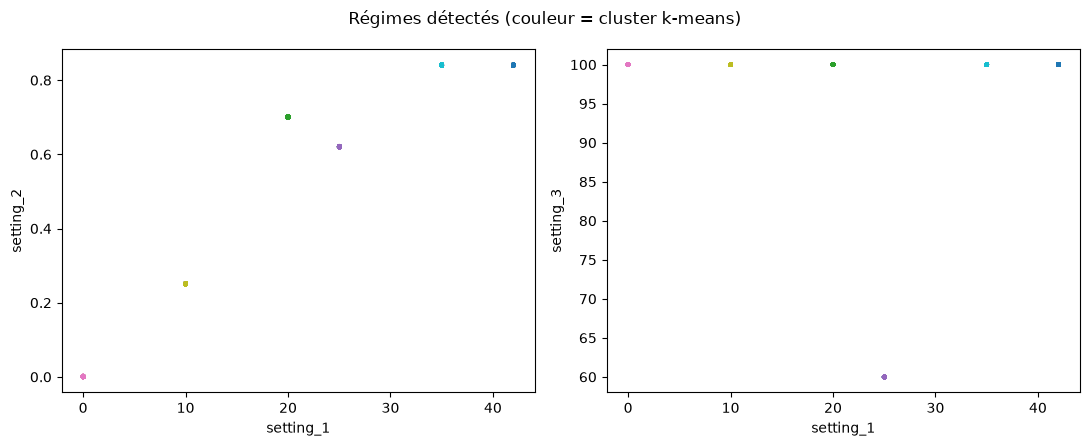

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sample = train.sample(5000, random_state=42)  # échantillon pour un nuage de points lisible

axes[0].scatter(sample["setting_1"], sample["setting_2"], c=sample["regime"], cmap="tab10", s=5)
axes[0].set_xlabel("setting_1")
axes[0].set_ylabel("setting_2")

axes[1].scatter(sample["setting_1"], sample["setting_3"], c=sample["regime"], cmap="tab10", s=5)
axes[1].set_xlabel("setting_1")
axes[1].set_ylabel("setting_3")

fig.suptitle("Régimes détectés (couleur = cluster k-means)")
fig.tight_layout()

**Ce que montrent ces figures** : chaque couleur est un régime détecté par k-means. On
s'attend à voir 6 amas de points bien séparés et compacts (pas un dégradé continu de couleurs)
: ça confirmerait que les moteurs FD002 opèrent réellement à des points de fonctionnement
fixes et discrets, comme l'annonce le readme, et pas sur une plage continue de réglages qu'on
aurait découpée arbitrairement en 6. Si c'est le cas, l'écart-type par régime calculé
juste avant devrait être proche de 0 pour les trois réglages — c'est la confirmation
numérique de ce que montre la figure visuellement.